# Bitcoin Scam Classification using Machine Learning

1. Introduction

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


In [14]:

# Load dataset
df = pd.read_csv("Dataset/Bitcoin_Scam_Detection_Dataset_2025.csv")
df.head()


,message_text,label,scam_type,platform,contains_link,btc_address_present,urgency_level,promised_return_pct,sentiment_score,message_length,hour,dayofweek,is_weekend
0,Bitcoin price shows strong resistance near 65k.,legit,none,Email,No,No,low,0,-0.554,47,15,4,0
1,Tips for long-term crypto investment.,legit,none,WhatsApp,No,No,low,0,-0.940,37,4,5,1
2,Tips for long-term crypto investment.,legit,none,Discord,No,No,low,0,0.122,37,11,4,0
3,Latest Bitcoin market update and trends.,legit,none,Discord,No,No,medium,0,0.619,40,17,4,0
4,Latest Bitcoin market update and trends.,legit,none,Email,No,No,medium,0,-0.689,40,2,0,0


## 2. Data Preprocessing

In [15]:

# Encode target
df['label'] = df['label'].map({'legit': 0, 'scam': 1})

# Convert Yes/No
df['contains_link'] = df['contains_link'].map({'Yes':1,'No':0})
df['btc_address_present'] = df['btc_address_present'].map({'Yes':1,'No':0})

# One-hot encoding
df = pd.get_dummies(df, columns=['platform','urgency_level'], drop_first=True)

df.head()


,message_text,label,scam_type,contains_link,btc_address_present,promised_return_pct,sentiment_score,message_length,hour,dayofweek,is_weekend,platform_Email,platform_Telegram,platform_Twitter,platform_WhatsApp,urgency_level_low,urgency_level_medium
0,Bitcoin price shows strong resistance near 65k.,0,none,0,0,0,-0.554,47,15,4,0,True,False,False,False,True,False
1,Tips for long-term crypto investment.,0,none,0,0,0,-0.940,37,4,5,1,False,False,False,True,True,False
2,Tips for long-term crypto investment.,0,none,0,0,0,0.122,37,11,4,0,False,False,False,False,True,False
3,Latest Bitcoin market update and trends.,0,none,0,0,0,0.619,40,17,4,0,False,False,False,False,False,True
4,Latest Bitcoin market update and trends.,0,none,0,0,0,-0.689,40,2,0,0,True,False,False,False,False,True


## 3. EDA

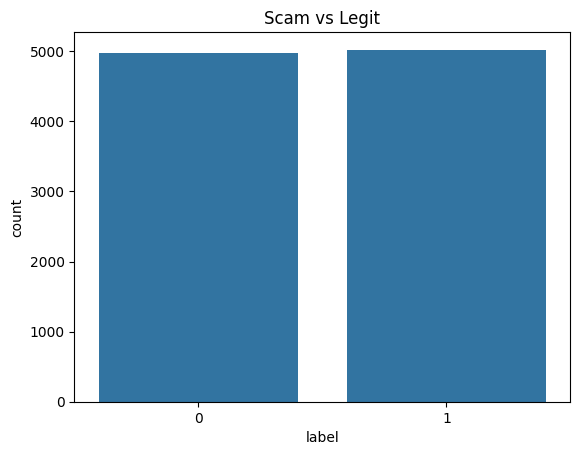

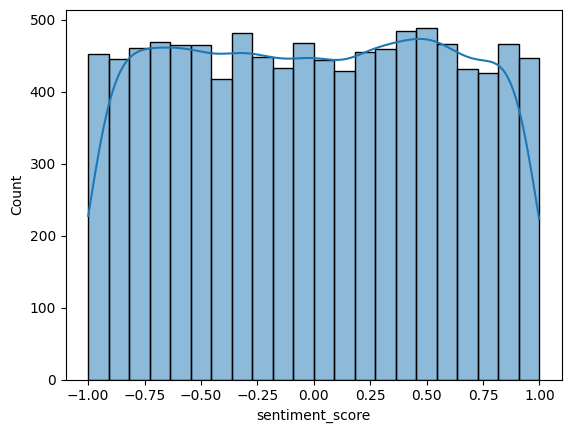

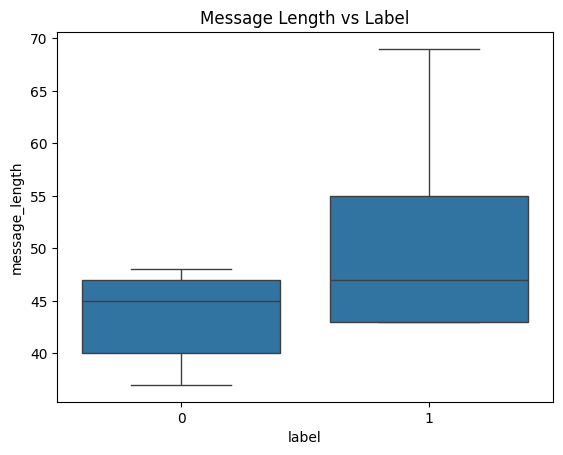

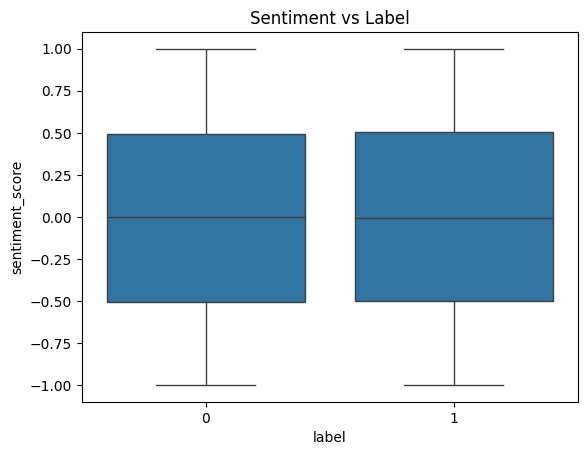

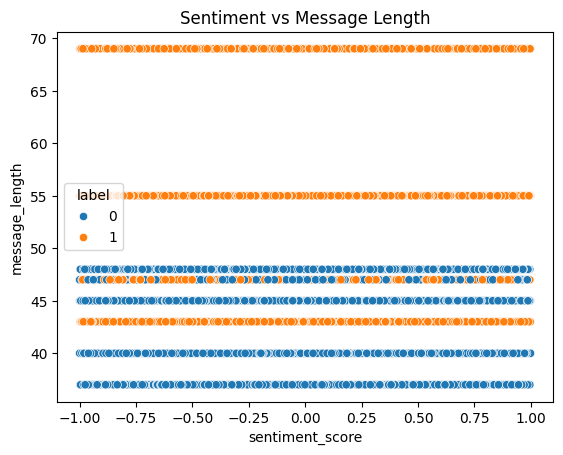

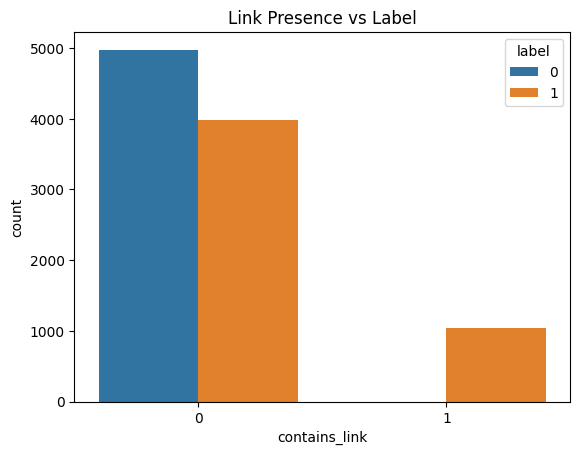

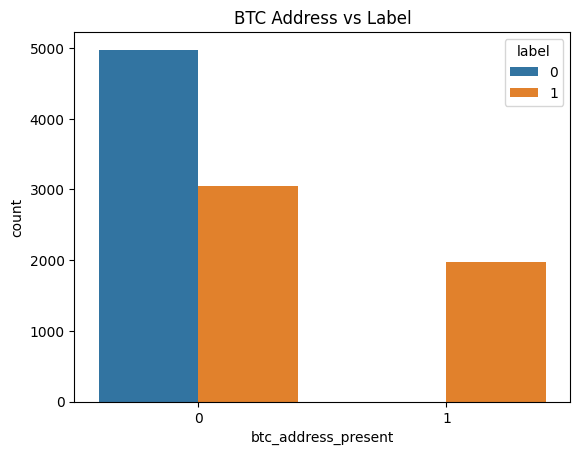

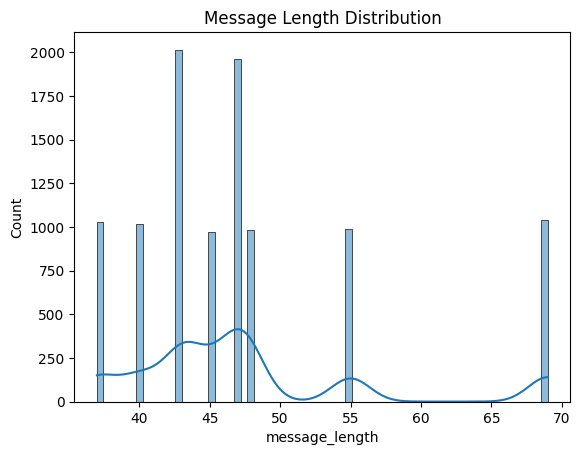

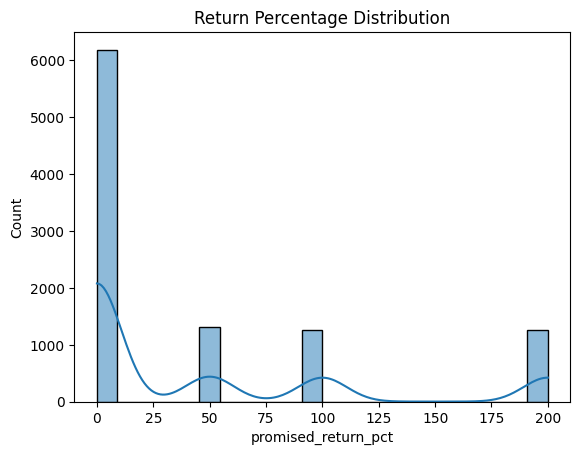

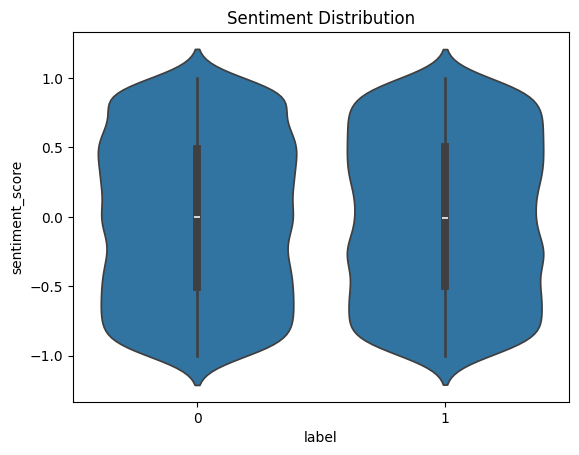

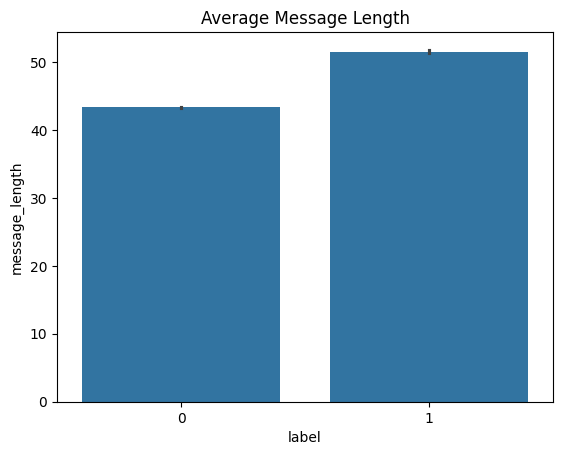

In [16]:

sns.countplot(x='label', data=df)
plt.title("Scam vs Legit")
plt.show()

sns.histplot(df['sentiment_score'], kde=True)
plt.show()


sns.boxplot(x='label', y='message_length', data=df)
plt.title("Message Length vs Label")
plt.show()

sns.boxplot(x='label', y='sentiment_score', data=df)
plt.title("Sentiment vs Label")
plt.show()

sns.scatterplot(x='sentiment_score', y='message_length', hue='label', data=df)
plt.title("Sentiment vs Message Length")
plt.show()

sns.countplot(x='contains_link', hue='label', data=df)
plt.title("Link Presence vs Label")
plt.show()

sns.countplot(x='btc_address_present', hue='label', data=df)
plt.title("BTC Address vs Label")
plt.show()

sns.histplot(df['message_length'], kde=True)
plt.title("Message Length Distribution")
plt.show()

sns.histplot(df['promised_return_pct'], kde=True)
plt.title("Return Percentage Distribution")
plt.show()

sns.violinplot(x='label', y='sentiment_score', data=df)
plt.title("Sentiment Distribution")
plt.show()

sns.barplot(x='label', y='message_length', data=df)
plt.title("Average Message Length")
plt.show()


## 4. Word2Vec Feature Extraction

In [17]:

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

df['tokens'] = df['message_text'].apply(lambda x: word_tokenize(x.lower()))

w2v_model = Word2Vec(df['tokens'], vector_size=100, window=5, min_count=1)

def avg_vector(tokens):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

df['w2v'] = df['tokens'].apply(avg_vector)

w2v_df = pd.DataFrame(df['w2v'].tolist())
df = pd.concat([df, w2v_df], axis=1)


ModuleNotFoundError: No module named 'nltk'

## 5. Train-Test Split

In [ ]:

X = df.drop(columns=['label','message_text','tokens','w2v'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


## 6. ML Models

In [18]:

from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier
from sklearn.ensemble import StackingClassifier

# Models
xgb = XGBClassifier()
lgbm = LGBMClassifier()
adb = AdaBoostClassifier()

# Stacking
stack = StackingClassifier(
    estimators=[('sgd', SGDClassifier()), ('pa', PassiveAggressiveClassifier())],
    final_estimator=SGDClassifier()
)


C:\Users\Charmi\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


## 7. Training & Evaluation

In [19]:

models = {'XGB':xgb,'LGBM':lgbm,'AdaBoost':adb,'Stacking':stack}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


NameError: name 'X_train' is not defined

8. CONFUSION MATRIX

In [21]:


from sklearn.metrics import confusion_matrix

# Using last model (or choose XGB)
model = xgb
preds = model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

NameError: name 'X_test' is not defined

9. PERFORMANCE TABLE

In [22]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=['Model','Accuracy'])
results_df

NameError: name 'X_train' is not defined

10. PREDICTION ON TEST DATA

In [23]:
test_df = pd.read_csv("Dataset/testdata.csv")

# Preprocessing same as training
test_df['contains_link'] = test_df['contains_link'].map({'Yes':1,'No':0})
test_df['btc_address_present'] = test_df['btc_address_present'].map({'Yes':1,'No':0})

test_df = pd.get_dummies(test_df, columns=['platform','urgency_level'], drop_first=True)

# Word2Vec
test_df['tokens'] = test_df['message_text'].apply(lambda x: word_tokenize(x.lower()))
test_df['w2v'] = test_df['tokens'].apply(avg_vector)

w2v_test = pd.DataFrame(test_df['w2v'].tolist())
test_df = pd.concat([test_df, w2v_test], axis=1)

X_testdata = test_df.drop(columns=['message_text','tokens','w2v'])

# Use trained model
predictions = xgb.predict(X_testdata)

test_df['Prediction'] = predictions

test_df.head()

NameError: name 'word_tokenize' is not defined